# Modelo 3: Support Vector Regression (SVR)
**Fase CRISP-DM:** Modeling  

## Descripción
SVR (Support Vector Regression) aplica la teoría de máquinas de vectores soporte 
al problema de regresión. Es un modelo de Machine Learning que captura relaciones 
no lineales mediante el **kernel RBF** (Radial Basis Function).

> ⚠️ **IMPORTANTE:** SVR es muy sensible a la escala de los datos.  
> Es **OBLIGATORIO** normalizar con `StandardScaler` antes del entrenamiento.

## Estrategia
Al igual que en Bayesian Ridge, se transforma la serie en un problema supervisado
mediante ventana deslizante. Se entrena un modelo `MultiOutputSVR` para predecir
los 4 sensores simultáneamente con ventana de 48h y 168h.

## Horizontes de predicción
- **1h** → benchmark  
- **24h** → predicción iterativa  
- **168h** → predicción iterativa (1 semana)  

## Métricas
- **RMSE** (Root Mean Squared Error) en veh/h  
- **R²** (coeficiente de determinación)

## Paso 1: Carga de datos y configuración del entorno

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Carga de los tres splits cronológicos
# ---------------------------------------------------------------------------
train_df = pd.read_csv('../../data/processed/Split_Datasets/data_train.csv')
val_df   = pd.read_csv('../../data/processed/Split_Datasets/data_val.csv')
test_df  = pd.read_csv('../../data/processed/Split_Datasets/data_test.csv')

def preparar_indice_temporal(df):
    """Convierte 'fecha' en índice datetime con frecuencia horaria estricta."""
    df['fecha'] = pd.to_datetime(df['fecha'])
    df.set_index('fecha', inplace=True)
    df.sort_index(inplace=True)
    df = df.asfreq('h')
    return df

train_df = preparar_indice_temporal(train_df)
val_df   = preparar_indice_temporal(val_df)
test_df  = preparar_indice_temporal(test_df)

cols_endogenas  = [col for col in train_df.columns
                   if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col]
cols_exogenas   = ['hora', 'dia_semana', 'mes', 'es_finde']
cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]

print("--- ESTRUCTURA DE DATOS ---")
print(f"Train : {train_df.shape} | {train_df.index.min()} → {train_df.index.max()}")
print(f"Val   : {val_df.shape}   | {val_df.index.min()} → {val_df.index.max()}")
print(f"Test  : {test_df.shape}  | {test_df.index.min()} → {test_df.index.max()}")
print(f"\nColumnas objetivo (intensidad): {cols_intensidad}")

--- ESTRUCTURA DE DATOS ---
Train : (16080, 16) | 2024-01-01 00:00:00 → 2025-10-31 23:00:00
Val   : (1464, 16)   | 2025-11-01 00:00:00 → 2025-12-31 23:00:00
Test  : (1416, 16)  | 2026-01-01 00:00:00 → 2026-02-28 23:00:00

Columnas objetivo (intensidad): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782']


## Paso 1.1: Imputación de valores nulos

In [3]:
def limpiar_nulos(df, cols_endo):
    df[cols_endo] = df[cols_endo].interpolate(method='linear', limit_direction='both')
    df['hora']       = df.index.hour
    df['dia_semana'] = df.index.dayofweek
    df['mes']        = df.index.month
    df['es_finde']   = (df['dia_semana'] >= 5).astype(int)
    return df

train_df = limpiar_nulos(train_df, cols_endogenas)
val_df   = limpiar_nulos(val_df,   cols_endogenas)
test_df  = limpiar_nulos(test_df,  cols_endogenas)

nulos_total = (train_df.isnull().sum().sum() +
               val_df.isnull().sum().sum()   +
               test_df.isnull().sum().sum())
print(f"✅ Nulos totales tras imputación: {nulos_total}")

✅ Nulos totales tras imputación: 0


## Paso 2: Construcción del dataset supervisado (ventana deslizante)
Se reutiliza la misma función de ventana deslizante que en el modelo Bayesian Ridge.

In [4]:
def crear_dataset_supervisado(df, cols_target, cols_exog, window_size):
    """
    Transforma la serie temporal en un problema de regresión supervisada.

    X = [valores históricos de cols_target en t-window_size … t-1] + [exógenas en t]
    y = [valores de cols_target en t]
    """
    X_list, y_list = [], []
    datos_target = df[cols_target].values
    datos_exog   = df[cols_exog].values

    for i in range(window_size, len(df)):
        ventana  = datos_target[i - window_size : i].flatten()
        contexto = datos_exog[i]
        X_list.append(np.concatenate([ventana, contexto]))
        y_list.append(datos_target[i])

    return np.array(X_list), np.array(y_list)

# ---------------------------------------------------------------------------
# Ventana de 48 horas — configuración principal
# ---------------------------------------------------------------------------
WINDOW_SIZE = 48

print(f"Construyendo datasets supervisados con ventana de {WINDOW_SIZE} horas...")

X_train, y_train = crear_dataset_supervisado(train_df, cols_intensidad, cols_exogenas, WINDOW_SIZE)
X_val,   y_val   = crear_dataset_supervisado(val_df,   cols_intensidad, cols_exogenas, WINDOW_SIZE)
X_test,  y_test  = crear_dataset_supervisado(test_df,  cols_intensidad, cols_exogenas, WINDOW_SIZE)

print(f"✅ X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"✅ X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"✅ X_test : {X_test.shape}  | y_test : {y_test.shape}")

Construyendo datasets supervisados con ventana de 48 horas...
✅ X_train: (16032, 196) | y_train: (16032, 4)
✅ X_val  : (1416, 196)   | y_val  : (1416, 4)
✅ X_test : (1368, 196)  | y_test : (1368, 4)


## Paso 3: Normalización con StandardScaler
**Obligatoria para SVR.** El scaler se ajusta SÓLO con train para evitar data leakage.

In [5]:
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------------------
# Normalización de X (features)
# CRITICAL: fit() sólo sobre train — transform() sobre val y test
# ---------------------------------------------------------------------------
scaler_X = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train)  # ajusta + transforma
X_val_sc   = scaler_X.transform(X_val)         # sólo transforma
X_test_sc  = scaler_X.transform(X_test)        # sólo transforma

# ---------------------------------------------------------------------------
# Normalización de y (targets) — mejora estabilidad numérica del SVR
# ---------------------------------------------------------------------------
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
y_test_sc  = scaler_y.transform(y_test)

print("✅ Normalización completada.")
print(f"   Media  X_train (primeras 3 features): {scaler_X.mean_[:3].round(2)}")
print(f"   Std    X_train (primeras 3 features): {scaler_X.scale_[:3].round(2)}")

✅ Normalización completada.
   Media  X_train (primeras 3 features): [3037.39 2963.92 3473.34]
   Std    X_train (primeras 3 features): [1731.58 2004.64 1822.98]


## Paso 4: Entrenamiento del modelo SVR
Se usa `MultiOutputRegressor` para predecir los 4 sensores simultáneamente.  

**Hiperparámetros iniciales:**
- `kernel='rbf'` → captura relaciones no lineales  
- `C=100` → penalización de errores  
- `epsilon=0.1` → margen de tolerancia  
- `gamma='scale'` → escala automática del kernel  

> Si el entrenamiento tarda demasiado (>30 min), prueba `LinearSVR` en el Paso 4.1

In [6]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
import time

# ---------------------------------------------------------------------------
# Definición del modelo SVR con kernel RBF
# ---------------------------------------------------------------------------
svr_base = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1,
    gamma='scale'
)

modelo_svr = MultiOutputRegressor(svr_base, n_jobs=-1)

print("⏳ Entrenando SVR (kernel RBF, C=100, epsilon=0.1)...")
print("   Esto puede tardar entre 5 y 30 minutos según el hardware.\n")

t0 = time.time()
modelo_svr.fit(X_train_sc, y_train_sc)
t1 = time.time()

print(f"✅ SVR entrenado en {(t1 - t0) / 60:.1f} minutos.")
print(f"   Features de entrada : {X_train_sc.shape[1]}")
print(f"   Variables objetivo  : {y_train_sc.shape[1]}")

⏳ Entrenando SVR (kernel RBF, C=100, epsilon=0.1)...
   Esto puede tardar entre 5 y 30 minutos según el hardware.

✅ SVR entrenado en 17.5 minutos.
   Features de entrada : 196
   Variables objetivo  : 4


### Paso 4.1 (ALTERNATIVA): LinearSVR si el RBF es demasiado lento

In [7]:
# ---------------------------------------------------------------------------
# ⚡ ALTERNATIVA MÁS RÁPIDA: LinearSVR
# Ejecutar esta celda SOLO si el SVR-RBF de arriba tardó demasiado
# ---------------------------------------------------------------------------

# from sklearn.svm import LinearSVR
# from sklearn.multioutput import MultiOutputRegressor
# import time

# svr_lineal = LinearSVR(C=1.0, epsilon=0.1, max_iter=2000)
# modelo_svr = MultiOutputRegressor(svr_lineal, n_jobs=-1)

# print("⏳ Entrenando LinearSVR...")
# t0 = time.time()
# modelo_svr.fit(X_train_sc, y_train_sc)
# t1 = time.time()
# print(f"✅ LinearSVR entrenado en {(t1 - t0) / 60:.1f} minutos.")

print("(Celda alternativa — descomentar si es necesario)")

(Celda alternativa — descomentar si es necesario)


## Paso 5: Predicción multi-horizonte
Para horizontes > 1h se usa predicción iterativa con desnormalización incluida.

In [8]:
def predecir_iterativo_svr(modelo, scaler_X, scaler_y, ultimo_train,
                            df_futuro, cols_target, cols_exog, window_size, steps):
    """
    Predicción iterativa para SVR con normalización/desnormalización integrada.
    
    Parámetros
    ----------
    modelo      : MultiOutputRegressor entrenado
    scaler_X    : StandardScaler ajustado sobre X_train
    scaler_y    : StandardScaler ajustado sobre y_train
    ultimo_train: últimas 'window_size' filas del train (valores reales sin escalar)
    df_futuro   : DataFrame de val o test (para variables exógenas)
    steps       : número de pasos a predecir

    Retorna
    -------
    np.ndarray desnormalizado de forma (steps, n_targets)
    """
    buffer = ultimo_train[cols_target].values[-window_size:].copy()
    predicciones = []

    for i in range(steps):
        exog_i = df_futuro[cols_exog].iloc[i].values
        x_i    = np.concatenate([buffer.flatten(), exog_i]).reshape(1, -1)

        # Normalizar el vector de features
        x_i_sc = scaler_X.transform(x_i)

        # Predecir en espacio normalizado
        pred_sc = modelo.predict(x_i_sc)   # shape (1, n_targets)

        # Desnormalizar la predicción
        pred = scaler_y.inverse_transform(pred_sc)[0]  # shape (n_targets,)
        predicciones.append(pred)

        # Actualizar buffer con el valor predicho (ya desnormalizado)
        buffer = np.vstack([buffer[1:], pred])

    return np.array(predicciones)

# ---------------------------------------------------------------------------
# Generación de predicciones sobre validación
# ---------------------------------------------------------------------------
ultimo_train = train_df.iloc[-WINDOW_SIZE:]
idx_val      = val_df.index

print("--- GENERANDO PREDICCIONES SOBRE VALIDACIÓN ---")

pred_1h   = predecir_iterativo_svr(modelo_svr, scaler_X, scaler_y, ultimo_train,
                                    val_df, cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=1)
print("✅ Predicción a  1 hora  completada.")

pred_24h  = predecir_iterativo_svr(modelo_svr, scaler_X, scaler_y, ultimo_train,
                                    val_df, cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=24)
print("✅ Predicción a 24 horas completada.")

pred_168h = predecir_iterativo_svr(modelo_svr, scaler_X, scaler_y, ultimo_train,
                                    val_df, cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=168)
print("✅ Predicción a 168 horas (1 semana) completada.")

df_pred_1h   = pd.DataFrame(pred_1h,   index=idx_val[:1],   columns=cols_intensidad)
df_pred_24h  = pd.DataFrame(pred_24h,  index=idx_val[:24],  columns=cols_intensidad)
df_pred_168h = pd.DataFrame(pred_168h, index=idx_val[:168], columns=cols_intensidad)

--- GENERANDO PREDICCIONES SOBRE VALIDACIÓN ---
✅ Predicción a  1 hora  completada.
✅ Predicción a 24 horas completada.
✅ Predicción a 168 horas (1 semana) completada.


## Paso 6: Evaluación de métricas (RMSE y R²)

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluar_predicciones(df_real, df_pred, cols_obj, etiqueta):
    print(f"\n[ HORIZONTE: {etiqueta} ]")
    rmse_vals, r2_vals = [], []
    for col in cols_obj:
        n    = len(df_pred)
        real = df_real[col].iloc[:n].values
        pred = df_pred[col].values
        mask = ~np.isnan(real) & ~np.isnan(pred)
        rmse = np.sqrt(mean_squared_error(real[mask], pred[mask]))
        r2   = r2_score(real[mask], pred[mask])
        rmse_vals.append(rmse)
        r2_vals.append(r2)
        print(f"  Sensor {col[-4:]}  →  RMSE: {rmse:>8.2f} veh/h  |  R²: {r2:>7.4f}")
    print(f"  {'─'*52}")
    print(f"  PROMEDIO GLOBAL   →  RMSE: {np.mean(rmse_vals):>8.2f} veh/h  |  R²: {np.mean(r2_vals):>7.4f}")
    return np.mean(rmse_vals), np.mean(r2_vals)

print("========================================")
print("   RESULTADOS SVR — VALIDACIÓN")
print("========================================")
rmse_1h,   r2_1h   = evaluar_predicciones(val_df, df_pred_1h,   cols_intensidad, " 1 HORA   (benchmark)")
rmse_24h,  r2_24h  = evaluar_predicciones(val_df, df_pred_24h,  cols_intensidad, "24 HORAS  (medio plazo)")
rmse_168h, r2_168h = evaluar_predicciones(val_df, df_pred_168h, cols_intensidad, "168 HORAS (largo plazo)")

print("\n--- TABLA RESUMEN SVR ---")
resumen = pd.DataFrame({
    'Horizonte'   : ['1h', '24h', '168h'],
    'RMSE (veh/h)': [rmse_1h, rmse_24h, rmse_168h],
    'R²'          : [r2_1h, r2_24h, r2_168h]
})
print(resumen.to_string(index=False))

   RESULTADOS SVR — VALIDACIÓN

[ HORIZONTE:  1 HORA   (benchmark) ]
  Sensor 3820  →  RMSE:   216.33 veh/h  |  R²:     nan
  Sensor 6642  →  RMSE:   141.10 veh/h  |  R²:     nan
  Sensor 6676  →  RMSE:   195.62 veh/h  |  R²:     nan
  Sensor 6782  →  RMSE:   510.27 veh/h  |  R²:     nan
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:   265.83 veh/h  |  R²:     nan

[ HORIZONTE: 24 HORAS  (medio plazo) ]
  Sensor 3820  →  RMSE:  1132.95 veh/h  |  R²:  0.2136
  Sensor 6642  →  RMSE:  1369.50 veh/h  |  R²: -0.5661
  Sensor 6676  →  RMSE:  2574.59 veh/h  |  R²: -0.9769
  Sensor 6782  →  RMSE:   745.44 veh/h  |  R²:  0.5962
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:  1455.62 veh/h  |  R²: -0.1833

[ HORIZONTE: 168 HORAS (largo plazo) ]
  Sensor 3820  →  RMSE:  1728.94 veh/h  |  R²:  0.1562
  Sensor 6642  →  RMSE:  1903.31 veh/h  |  R²: -0.0205
  Sensor 6676  →  RMSE:  1940.43 veh/h  |  R²:  0.0951
  Sensor 6782  →

## Paso 7: Visualización de resultados

✅ Gráfico guardado: 'grafico_svr_168h.png'


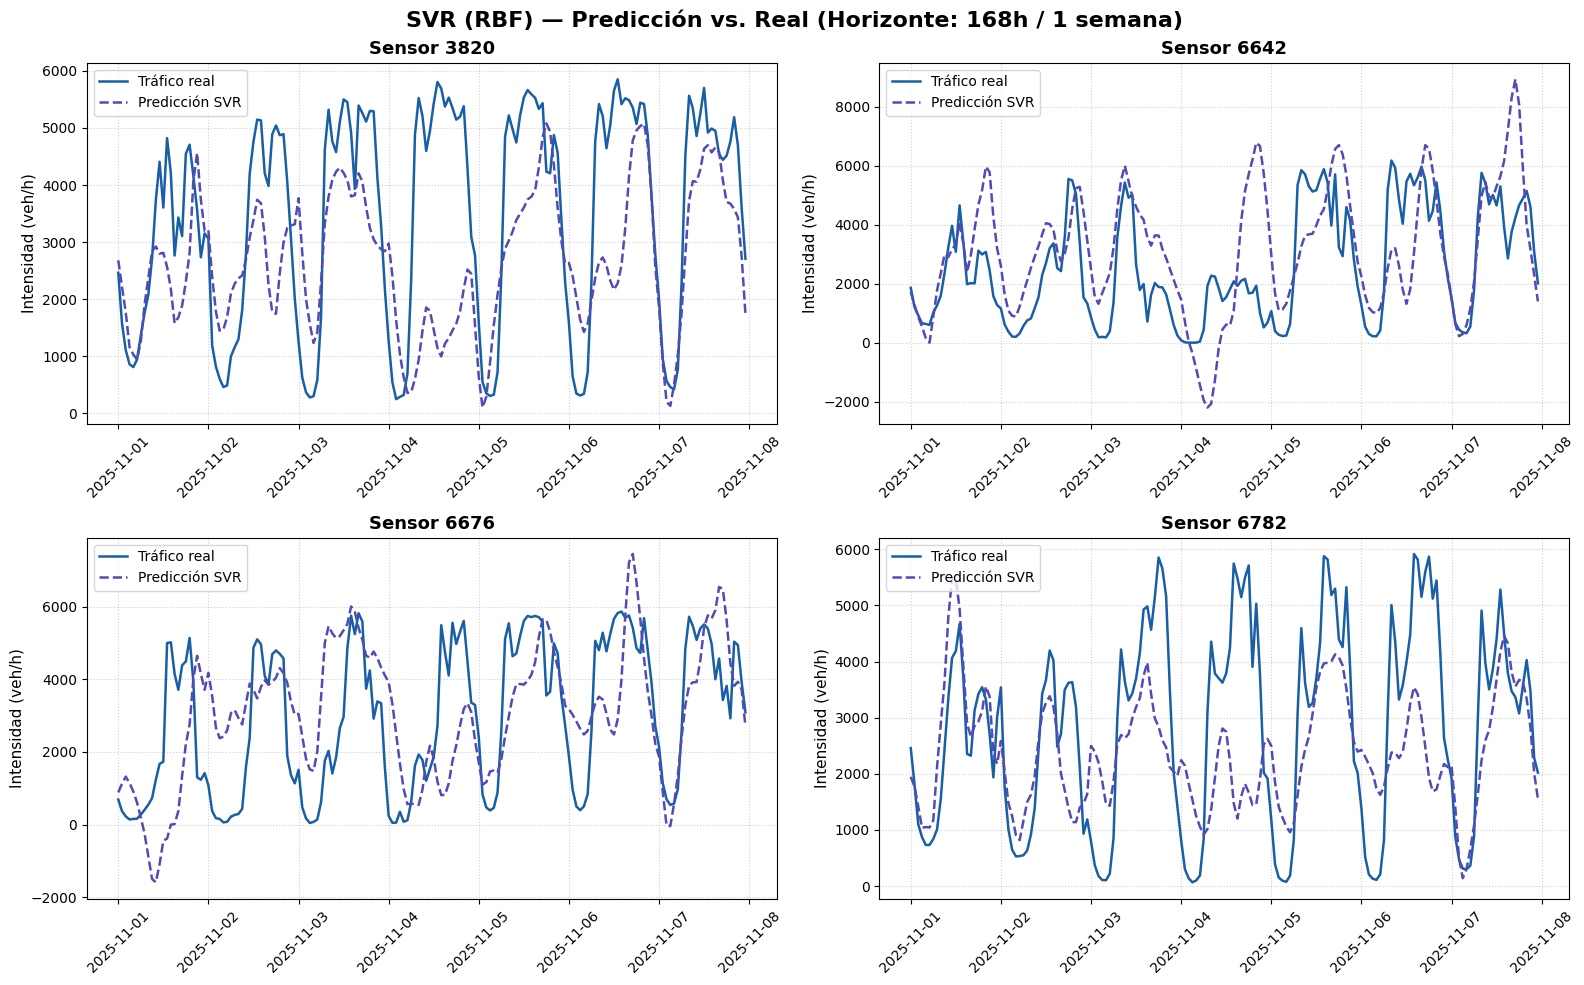

In [10]:
import matplotlib.pyplot as plt

plt.style.use('default')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
fig.suptitle('SVR (RBF) — Predicción vs. Real (Horizonte: 168h / 1 semana)',
             fontsize=16, fontweight='bold', y=0.98)
axes = axes.flatten()

for i, col in enumerate(cols_intensidad):
    ax = axes[i]
    sensor_id = col.split('_')[-1]

    ax.plot(val_df.index[:168], val_df[col].iloc[:168].values,
            label='Tráfico real', color='#185FA5', linewidth=1.8)
    ax.plot(df_pred_168h.index, df_pred_168h[col].values,
            label='Predicción SVR', color='#534AB7',
            linestyle='--', linewidth=1.8)

    ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('grafico_svr_168h.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado: 'grafico_svr_168h.png'")
plt.show()

## Paso 8: Búsqueda de hiperparámetros con GridSearchCV (opcional)
Si los resultados no son satisfactorios, se puede afinar el modelo con GridSearch.

In [11]:
# ---------------------------------------------------------------------------
# OPCIONAL: GridSearchCV para afinar C y epsilon
# ⚠️ Puede tardar varias horas — ejecutar sólo si es necesario
# ---------------------------------------------------------------------------

# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# param_grid = {
#     'estimator__C'      : [10, 100, 500],
#     'estimator__epsilon': [0.05, 0.1, 0.5],
#     'estimator__gamma'  : ['scale', 'auto']
# }

# tscv = TimeSeriesSplit(n_splits=3)  # validación cruzada para series temporales

# grid_search = GridSearchCV(
#     estimator=MultiOutputRegressor(SVR(kernel='rbf')),
#     param_grid=param_grid,
#     cv=tscv,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=2
# )

# grid_search.fit(X_train_sc, y_train_sc)
# print(f"Mejores parámetros: {grid_search.best_params_}")
# print(f"Mejor RMSE (CV): {-grid_search.best_score_:.2f}")

print("(Celda opcional — descomentar para ejecutar GridSearch)")

(Celda opcional — descomentar para ejecutar GridSearch)


## Paso 9: Evaluación final sobre Test

In [12]:
print("--- EVALUACIÓN FINAL SOBRE TEST (datos no vistos) ---")

ultimo_val = val_df.iloc[-WINDOW_SIZE:]

pred_test_1h   = predecir_iterativo_svr(modelo_svr, scaler_X, scaler_y, ultimo_val,
                                         test_df, cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=1)
pred_test_24h  = predecir_iterativo_svr(modelo_svr, scaler_X, scaler_y, ultimo_val,
                                         test_df, cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=24)
pred_test_168h = predecir_iterativo_svr(modelo_svr, scaler_X, scaler_y, ultimo_val,
                                         test_df, cols_intensidad, cols_exogenas, WINDOW_SIZE, steps=168)

df_pred_test_1h   = pd.DataFrame(pred_test_1h,   index=test_df.index[:1],   columns=cols_intensidad)
df_pred_test_24h  = pd.DataFrame(pred_test_24h,  index=test_df.index[:24],  columns=cols_intensidad)
df_pred_test_168h = pd.DataFrame(pred_test_168h, index=test_df.index[:168], columns=cols_intensidad)

print("\n========================================")
print("   RESULTADOS SVR — TEST FINAL")
print("========================================")
evaluar_predicciones(test_df, df_pred_test_1h,   cols_intensidad, " 1 HORA   (benchmark)")
evaluar_predicciones(test_df, df_pred_test_24h,  cols_intensidad, "24 HORAS  (medio plazo)")
evaluar_predicciones(test_df, df_pred_test_168h, cols_intensidad, "168 HORAS (largo plazo)")

--- EVALUACIÓN FINAL SOBRE TEST (datos no vistos) ---

   RESULTADOS SVR — TEST FINAL

[ HORIZONTE:  1 HORA   (benchmark) ]
  Sensor 3820  →  RMSE:   945.37 veh/h  |  R²:     nan
  Sensor 6642  →  RMSE:   758.71 veh/h  |  R²:     nan
  Sensor 6676  →  RMSE:   933.18 veh/h  |  R²:     nan
  Sensor 6782  →  RMSE:   621.57 veh/h  |  R²:     nan
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:   814.71 veh/h  |  R²:     nan

[ HORIZONTE: 24 HORAS  (medio plazo) ]
  Sensor 3820  →  RMSE:   755.07 veh/h  |  R²:  0.6647
  Sensor 6642  →  RMSE:   616.86 veh/h  |  R²:  0.8110
  Sensor 6676  →  RMSE:   716.49 veh/h  |  R²:  0.6485
  Sensor 6782  →  RMSE:   367.89 veh/h  |  R²:  0.8639
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:   614.08 veh/h  |  R²:  0.7470

[ HORIZONTE: 168 HORAS (largo plazo) ]
  Sensor 3820  →  RMSE:   844.06 veh/h  |  R²:  0.7568
  Sensor 6642  →  RMSE:  1066.46 veh/h  |  R²:  0.6867
  Sensor 6676  →

(911.392771314203, 0.6998342298180307)